In [1]:
!pip install torch torchvision transformers Pillow matplotlib pandas -q


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
from google.colab import files
import io

print("All imports successful.")
print(f"PyTorch version: {torch.__version__}")

All imports successful.
PyTorch version: 2.10.0+cu128


In [3]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()
print("CLIP model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded.


In [4]:
prompts = {
    "sad": {
        "V1": "An album cover art that conveys sadness emotions featuring figure somehow, rise",
        "V2": "A dark, moody album cover art conveying sadness, fear emotions. Imagery: darkness, memories, shadows, pain, light. Style: dramatic, cinematic, high contrast.",
        "V3": "Album cover: SADNESS and fear. Visual palette: deep blues and purples. Imagery: shadows, cry, night, fall, darkness. Mood: melancholic, brooding. Style: cinematic photography, dramatic lighting.",
        "V4": "A cinematic album cover depicting the emotional journey of sadness and fear. Scene: shadows, cry, night, fall, darkness bathed in deep blues and purples. Mood: melancholic and brooding. Art direction: dramatic lighting, high contrast, professional photography.",
        "V5": "A cinematic album cover depicting grief and introspection. Scene: solitary figure in deep violet fog beneath a streetlamp, bare winter trees, fallen leaves, deep blues and purples. Mood: melancholic, isolated, and quietly hopeful. Art direction: atmospheric lighting, soft focus, professional photography.",
    },
    "pop": {
        "V1": "An album cover art that conveys joy emotions featuring bright dancing alive",
        "V2": "A vibrant, energetic album cover art conveying joy emotions. Imagery: bright, dancing, alive, joy, light. Style: dramatic, cinematic, high contrast.",
        "V3": "Album cover: JOY. Visual palette: warm brightness and golden tones. Imagery: bright, dancing, alive, joy, light. Mood: euphoric, energetic. Style: cinematic photography, dramatic lighting.",
        "V4": "A cinematic album cover depicting the emotional journey of joy and energy. Scene: bright, dancing, alive, soar, free bathed in warm brightness and golden tones. Mood: euphoric and energetic. Art direction: dramatic lighting, high contrast, professional photography.",
        "V5": "A cinematic album cover depicting pure joy and celebration. Scene: woman dancing in golden-hour confetti shower, arms outstretched, warm pinks and oranges, glitter and light bokeh. Mood: euphoric, free, alive. Art direction: sunset backlight, shallow depth of field, photorealistic.",
    },
    "rap": {
        "V1": "An album cover art that conveys fear emotions featuring ever seem",
        "V2": "A dark, dramatic album cover art conveying fear emotions. Imagery: city, rise, hustle, top, run. Style: dramatic, cinematic, high contrast.",
        "V3": "Album cover: FEAR. Visual palette: desaturated greys and cold blues. Imagery: rise, city, hustle, grind, watch. Mood: tense, determined. Style: cinematic photography, dramatic lighting.",
        "V4": "A cinematic album cover depicting determination and ambition. Scene: figure between large rock formations, dramatic sky, conviction and isolation. Mood: determined and powerful. Art direction: dramatic lighting, high contrast, professional photography.",
        "V5": "A cinematic hip-hop album cover depicting confidence, ambition, and urban power. Scene: silhouetted figure in hat and gold chains crouching on rooftop overlooking city skyline at crimson sunset, Empire State Building visible. Mood: triumphant and determined. Art direction: dramatic low-angle shot, warm golden-red tones, graphic novel illustration style.",
    },
}
print("Prompts defined.")

Prompts defined.


In [5]:
print("Upload all 15 PNG images when prompted.")
print("Files needed:")
expected_files = [
    "sad_introspective_v1.png", "sad_introspective_v2.png",
    "sad_introspective_v3.png", "sad_introspective_v4.png", "sad_v5.png",
    "upbeat_pop_v1.png", "upbeat_pop_v2.png",
    "upbeat_pop_v3.png", "upbeat_pop_v4.png", "pop_v5.png",
    "rap_v1.png", "rap_v2.png", "rap_v3.png", "rap_v4.png", "rap_v5.png",
]
for f in expected_files:
    print(f"  - {f}")

uploaded = files.upload()
print(f"\\nUploaded {len(uploaded)} files.")

Upload all 15 PNG images when prompted.
Files needed:
  - sad_introspective_v1.png
  - sad_introspective_v2.png
  - sad_introspective_v3.png
  - sad_introspective_v4.png
  - sad_v5.png
  - upbeat_pop_v1.png
  - upbeat_pop_v2.png
  - upbeat_pop_v3.png
  - upbeat_pop_v4.png
  - pop_v5.png
  - rap_v1.png
  - rap_v2.png
  - rap_v3.png
  - rap_v4.png
  - rap_v5.png


Saving pop_v5.png to pop_v5.png
Saving rap_v1.png to rap_v1.png
Saving rap_v2.png to rap_v2.png
Saving rap_v3.png to rap_v3.png
Saving rap_v4.png to rap_v4.png
Saving rap_v5.png to rap_v5.png
Saving sad_introspective_v1.png to sad_introspective_v1.png
Saving sad_introspective_v2.png to sad_introspective_v2.png
Saving sad_introspective_v3.png to sad_introspective_v3.png
Saving sad_introspective_v4.png to sad_introspective_v4.png
Saving sad_v5.png to sad_v5.png
Saving upbeat_pop_v1.png to upbeat_pop_v1.png
Saving upbeat_pop_v2.png to upbeat_pop_v2.png
Saving upbeat_pop_v3.png to upbeat_pop_v3.png
Saving upbeat_pop_v4.png to upbeat_pop_v4.png
\nUploaded 15 files.


In [6]:
image_files = {
    "sad": {
        "V1": "sad_introspective_v1.png",
        "V2": "sad_introspective_v2.png",
        "V3": "sad_introspective_v3.png",
        "V4": "sad_introspective_v4.png",
        "V5": "sad_v5.png",
    },
    "pop": {
        "V1": "upbeat_pop_v1.png",
        "V2": "upbeat_pop_v2.png",
        "V3": "upbeat_pop_v3.png",
        "V4": "upbeat_pop_v4.png",
        "V5": "pop_v5.png",
    },
    "rap": {
        "V1": "rap_v1.png",
        "V2": "rap_v2.png",
        "V3": "rap_v3.png",
        "V4": "rap_v4.png",
        "V5": "rap_v5.png",
    },
}
print("Image mapping defined.")

Image mapping defined.


In [7]:
def clip_score(image_path_or_bytes, text):
    if isinstance(image_path_or_bytes, bytes):
        image = Image.open(io.BytesIO(image_path_or_bytes)).convert("RGB")
    else:
        image = Image.open(image_path_or_bytes).convert("RGB")
    inputs = processor(
        text=[text], images=image,
        return_tensors="pt", padding=True, truncation=True, max_length=77
    )
    with torch.no_grad():
        outputs = model(**inputs)
    # Cosine similarity scaled by 100 (standard CLIP score convention)
    score = outputs.logits_per_image.item()
    return score

results = {}
print("Computing CLIP scores...")
print("-" * 50)

for genre in ["sad", "pop", "rap"]:
    results[genre] = {}
    for v in ["V1", "V2", "V3", "V4", "V5"]:
        fname = image_files[genre][v]
        prompt = prompts[genre][v]
        img_bytes = uploaded[fname]
        score = clip_score(img_bytes, prompt)
        results[genre][v] = score
        print(f"{genre.upper():4s} {v}: {score:.4f}")

print("\\nDone.")

Computing CLIP scores...
--------------------------------------------------
SAD  V1: 27.9861
SAD  V2: 25.5075
SAD  V3: 25.1533
SAD  V4: 20.3132
SAD  V5: 38.2583
POP  V1: 31.1778
POP  V2: 26.4533
POP  V3: 35.3195
POP  V4: 27.7956
POP  V5: 35.1672
RAP  V1: 23.5196
RAP  V2: 26.1434
RAP  V3: 27.4124
RAP  V4: 29.6794
RAP  V5: 36.7839
\nDone.


In [8]:
print("\\n" + "="*60)
print("CLIP SCORE RESULTS")
print("="*60)
print(f"{'Version':<8} {'Sad':>10} {'Pop':>10} {'Rap':>10}")
print("-"*40)
for v in ["V1","V2","V3","V4","V5"]:
    sad = results["sad"][v]
    pop = results["pop"][v]
    rap = results["rap"][v]
    print(f"{v:<8} {sad:>10.4f} {pop:>10.4f} {rap:>10.4f}")
print("-"*40)

# Print means and best version per genre
for genre in ["sad","pop","rap"]:
    scores = list(results[genre].values())
    best_v = max(results[genre], key=results[genre].get)
    print(f"{genre.upper()} — mean: {np.mean(scores):.4f}, best: {best_v} ({results[genre][best_v]:.4f})")

\n============================================================
CLIP SCORE RESULTS
Version         Sad        Pop        Rap
----------------------------------------
V1          27.9861    31.1778    23.5196
V2          25.5075    26.4533    26.1434
V3          25.1533    35.3195    27.4124
V4          20.3132    27.7956    29.6794
V5          38.2583    35.1672    36.7839
----------------------------------------
SAD — mean: 27.4437, best: V5 (38.2583)
POP — mean: 31.1827, best: V3 (35.3195)
RAP — mean: 28.7077, best: V5 (36.7839)


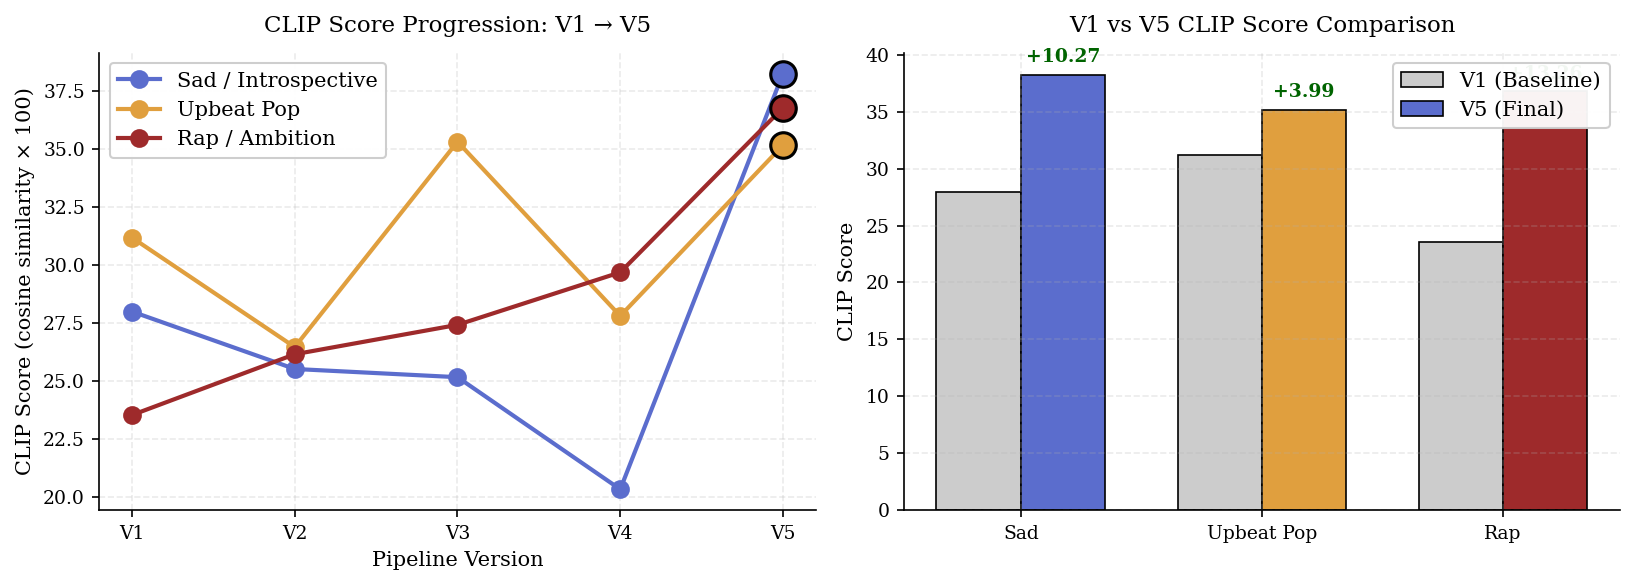

Figure saved.


In [9]:
mpl.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
})

GENRE_COLORS = {'sad': '#5b6dcd', 'pop': '#e09f3e', 'rap': '#9e2a2b'}
GENRE_LABELS = {'sad': 'Sad / Introspective', 'pop': 'Upbeat Pop', 'rap': 'Rap / Ambition'}
versions = ["V1","V2","V3","V4","V5"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: line plot of CLIP score progression
ax = axes[0]
for genre in ["sad","pop","rap"]:
    scores = [results[genre][v] for v in versions]
    ax.plot(versions, scores, marker='o', markersize=8, linewidth=2,
            label=GENRE_LABELS[genre], color=GENRE_COLORS[genre])
    # Highlight V5
    ax.scatter(["V5"], [results[genre]["V5"]], s=150, color=GENRE_COLORS[genre],
               edgecolor='black', linewidth=1.5, zorder=5)

ax.set_xlabel("Pipeline Version")
ax.set_ylabel("CLIP Score (cosine similarity × 100)")
ax.set_title("CLIP Score Progression: V1 → V5", pad=10)
ax.legend(loc='best', frameon=True, framealpha=0.95)

# Right: bar chart V5 scores compared to V1
ax2 = axes[1]
x = np.arange(3)
width = 0.35
genres = ["sad","pop","rap"]
v1_scores = [results[g]["V1"] for g in genres]
v5_scores = [results[g]["V5"] for g in genres]

bars1 = ax2.bar(x - width/2, v1_scores, width, label='V1 (Baseline)',
                color='#cccccc', edgecolor='black', linewidth=0.8)
bars5 = ax2.bar(x + width/2, v5_scores, width, label='V5 (Final)',
                color=[GENRE_COLORS[g] for g in genres],
                edgecolor='black', linewidth=0.8)

# Delta annotations
for i, (v1, v5, g) in enumerate(zip(v1_scores, v5_scores, genres)):
    delta = v5 - v1
    ax2.annotate(f'+{delta:.2f}' if delta >= 0 else f'{delta:.2f}',
                 xy=(i + width/2, v5),
                 xytext=(0, 4), textcoords='offset points',
                 ha='center', va='bottom', fontsize=9,
                 color='darkgreen' if delta >= 0 else 'red',
                 fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels([GENRE_LABELS[g].split('/')[0].strip() for g in genres])
ax2.set_ylabel("CLIP Score")
ax2.set_title("V1 vs V5 CLIP Score Comparison", pad=10)
ax2.legend(frameon=True, framealpha=0.95)

plt.tight_layout()
plt.savefig("fig_clip_scores.pdf", bbox_inches='tight', dpi=300)
plt.savefig("fig_clip_scores.png", bbox_inches='tight', dpi=200)
plt.show()
print("Figure saved.")

In [10]:
# Download the figure
files.download("fig_clip_scores.pdf")
files.download("fig_clip_scores.png")

# Print the full LaTeX table to copy into the paper
print("\\n% ── PASTE THIS INTO YOUR paper.tex ──────────────────────")
print("\\\\begin{table}[h]")
print("\\\\centering")
print("\\\\caption{CLIP similarity scores between generation prompts and")
print("corresponding generated images, computed using")
print("\\\\texttt{openai/clip-vit-base-patch32}. Higher scores indicate")
print("stronger semantic alignment between the image and its conditioning prompt.}")
print("\\\\label{tab:clip}")
print("\\\\setlength{\\\\extrarowheight}{3pt}")
print("\\\\rowcolors{2}{gray!10}{white}")
print("\\\\begin{tabular}{lrrr}")
print("\\\\toprule")
print("\\\\rowcolor{white}")
print("Version & Sad / Introspective & Upbeat Pop & Rap / Ambition \\\\\\\\")
print("\\\\midrule")
for v in ["V1","V2","V3","V4","V5"]:
    sad = results["sad"][v]
    pop = results["pop"][v]
    rap = results["rap"][v]
    bold_open = "\\\\textbf{" if v == "V5" else ""
    bold_close = "}" if v == "V5" else ""
    print(f"{bold_open}{v}{bold_close} & {bold_open}{sad:.2f}{bold_close} & {bold_open}{pop:.2f}{bold_close} & {bold_open}{rap:.2f}{bold_close} \\\\\\\\")
print("\\\\bottomrule")
print("\\\\end{tabular}")
print("\\\\end{table}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

\n% ── PASTE THIS INTO YOUR paper.tex ──────────────────────
\\begin{table}[h]
\\centering
\\caption{CLIP similarity scores between generation prompts and
corresponding generated images, computed using
\\texttt{openai/clip-vit-base-patch32}. Higher scores indicate
stronger semantic alignment between the image and its conditioning prompt.}
\\label{tab:clip}
\\setlength{\\extrarowheight}{3pt}
\\rowcolors{2}{gray!10}{white}
\\begin{tabular}{lrrr}
\\toprule
\\rowcolor{white}
Version & Sad / Introspective & Upbeat Pop & Rap / Ambition \\\\
\\midrule
V1 & 27.99 & 31.18 & 23.52 \\\\
V2 & 25.51 & 26.45 & 26.14 \\\\
V3 & 25.15 & 35.32 & 27.41 \\\\
V4 & 20.31 & 27.80 & 29.68 \\\\
\\textbf{V5} & \\textbf{38.26} & \\textbf{35.17} & \\textbf{36.78} \\\\
\\bottomrule
\\end{tabular}
\\end{table}
